# Building a SARIMA(X) model

## 0.0 Set-up

In [2]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.graphics.tsaplots import plot_pacf, plot_acf
import pmdarima as pm

In [3]:
### MOVE TO REQUIREMENTS ###
#!pip install pmdarima

## 0.1 Data import

Importing electricity price and generation data for Germany from February 2025 to February 2026!

ALERT: Data has to be in raw_data folder!!

In [4]:
path = "../../raw_data/"
file_price = "combined_energy_price_clean.csv"
file_generation = "final_generation_minimized.csv"

In [19]:
route_price = path + file_price
data_price = pd.read_csv(route_price, sep='\t')

/var/folders/sj/pc75w_ds6w72_p6qqgqy9m980000gn/T/ipykernel_68658/34444707.py:2: DtypeWarning: Columns (4) have mixed types. Specify dtype option on import or set low_memory=False.
  data_price = pd.read_csv(route_price, sep='\t')


In [21]:
route_generation = path + file_generation
data_generation = pd.read_csv(route_generation)

In [7]:
data_price = data_price[["DateTime(UTC)", "Price[Currency/MWh]","Sequence"]]

In [22]:
len(data_generation), len(data_price)

(396244, 378307)

## 1.0 Data cleaning and merging

### 1.1 Price

In [8]:
data_price = data_price[data_price["Sequence"] == 2]
data_price.drop(columns="Sequence", inplace=True)
data_price["date"] = pd.to_datetime(data_price["DateTime(UTC)"], format="%Y-%m-%d %H:%M:%S")
data_price.rename(columns={"Price[Currency/MWh]":"price"}, inplace=True)
data_price.drop(columns="DateTime(UTC)", inplace=True)
data_price = data_price.set_index('date')
data_price.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 186230 entries, 2020-12-29 00:30:00 to 2026-04-21 21:45:00
Data columns (total 1 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   price   186230 non-null  float64
dtypes: float64(1)
memory usage: 2.8 MB


### 1.2 Generation

In [9]:
data_generation.head()

,DateTime(UTC),ActualGenerationOutput[MW],ActualConsumption[MW]
0,2015-01-01 00:00:00,50247.45,1343.52
1,2015-01-01 00:15:00,49992.52,1329.77
2,2015-01-01 00:30:00,49587.40,1385.19
3,2015-01-01 00:45:00,49000.85,1431.61
4,2015-01-01 01:00:00,49377.68,1938.83


In [10]:
data_generation["generation"] = data_generation["ActualGenerationOutput[MW]"] - data_generation["ActualConsumption[MW]"]
data_generation["date"] = pd.to_datetime(data_generation["DateTime(UTC)"], format="%Y-%m-%d %H:%M:%S")
data_generation = data_generation[["date","generation"]]
data_generation = data_generation.set_index('date')
data_generation.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 396244 entries, 2015-01-01 00:00:00 to 2026-04-20 12:45:00
Data columns (total 1 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   generation  396244 non-null  float64
dtypes: float64(1)
memory usage: 6.0 MB


### 1.3 Time

In [11]:
start_date = pd.to_datetime("2025-02-01 00:00:00", format="%Y-%m-%d %H:%M:%S")
end_date = pd.to_datetime("2026-02-01 00:00:00", format="%Y-%m-%d %H:%M:%S")

In [12]:
data_price_2526 = data_price[(data_price.index >= start_date) & (data_price.index <= end_date)]
data_generation_2526 = data_generation[(data_generation.index >= start_date) & (data_generation.index <= end_date)]

In [16]:
len(data_price_2526)

35041

In [17]:
len(data_generation_2526)

35041

### 1.4 Scaling

<Axes: ylabel='Count'>

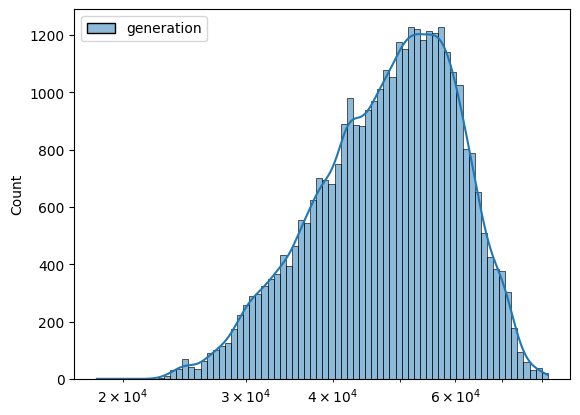

In [15]:
sns.histplot(data=data_generation_2526, kde=True, log_scale=True)

In [16]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

#data_generation_2526_log = np.log1p(data_generation_2526)

data_generation_2526_scaled = pd.DataFrame(
    scaler.fit_transform(data_generation_2526),
    index=data_generation_2526.index,
    columns=data_generation_2526.columns
)

<Axes: ylabel='Count'>

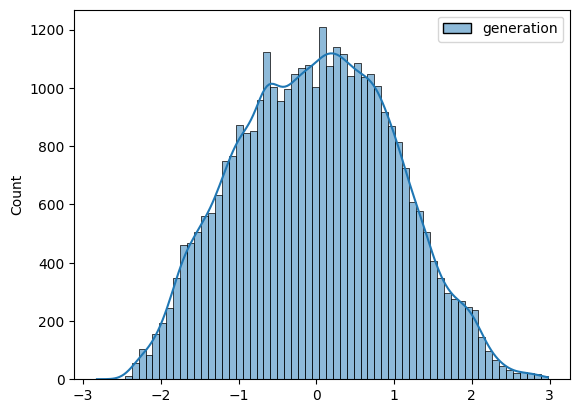

In [17]:
sns.histplot(data=data_generation_2526_scaled, kde=True)

## 2.0 Modelling

In [18]:
def plot_autocorrelation(y, d=0, D=0, m=96):
    y = pd.Series(y)
    if D > 0:
        for i in range(D):
            y = y.diff(m)
    if d > 0:
        for i in range(d):
            y = y.diff(1)
    fig = plt.figure(figsize=(20,10))
    ax1 = fig.add_subplot(2,1,1)
    ax2 = fig.add_subplot(2,2,3)
    ax3 = fig.add_subplot(2,2,4)
    ax1.plot(y)
    plot_acf(y, lags = 50, ax=ax2);
    plot_pacf(y, lags=50, method='ywm', ax=ax3, color='r');
    plt.show()

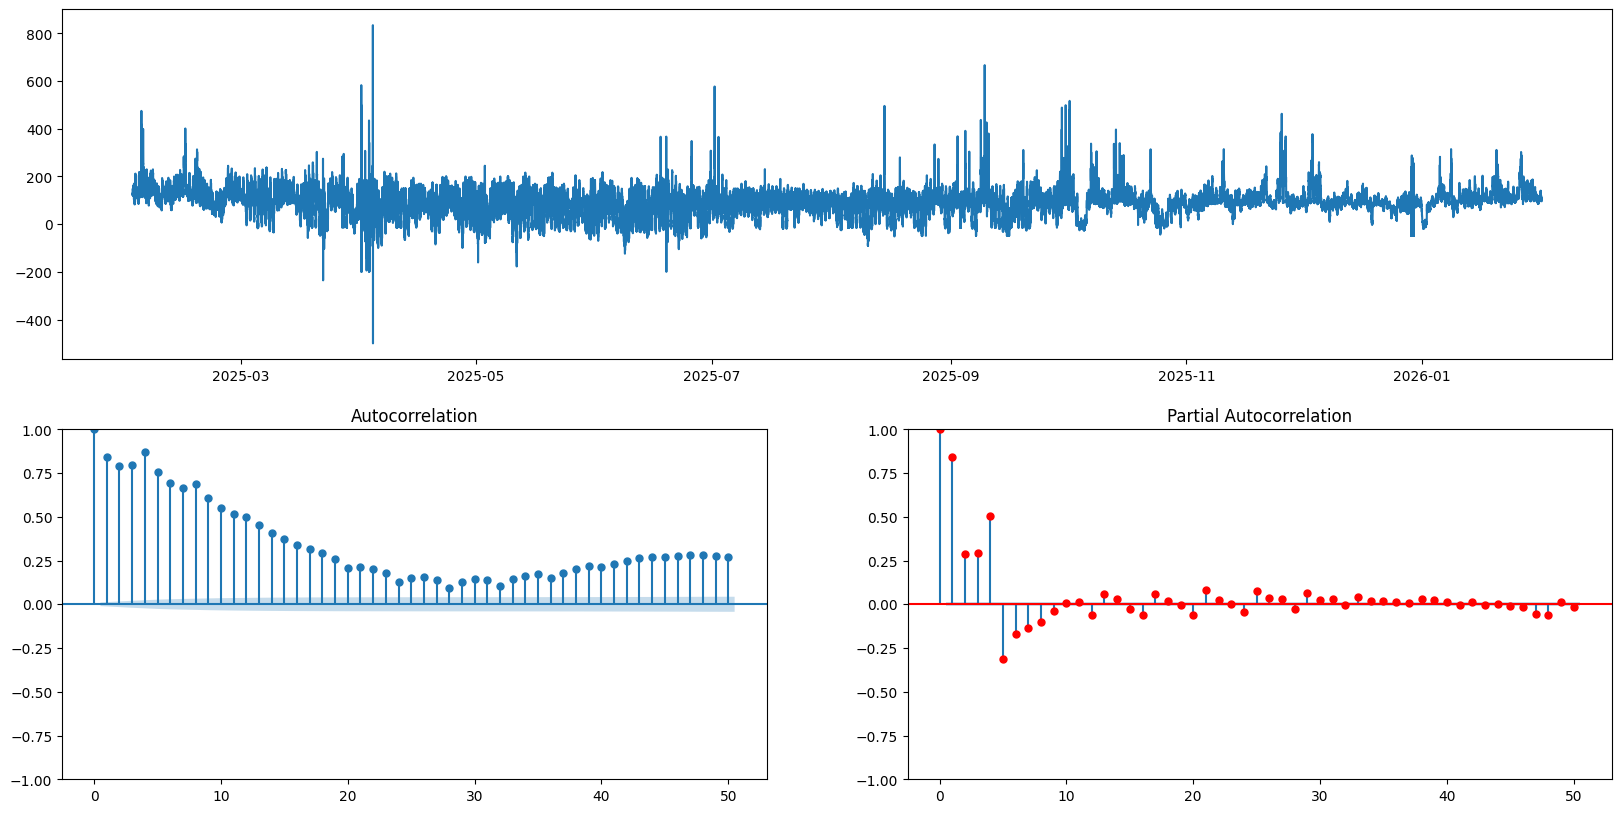

In [19]:
plot_autocorrelation(data_price_2526["price"])

In [62]:
# less data for the grid search
start_date = pd.to_datetime("2025-11-01 00:00:00", format="%Y-%m-%d %H:%M:%S")
end_date = pd.to_datetime("2026-02-01 00:00:00", format="%Y-%m-%d %H:%M:%S")
data_price_3m = data_price[(data_price.index >= start_date) & (data_price.index <= end_date)]
data_generation_3m = data_generation[(data_generation.index >= start_date) & (data_generation.index <= end_date)]

In [63]:
import pmdarima as pm
sarimax = pm.auto_arima(
                        data_price_3m,
                        exogenous=data_generation_3m,

                        # Non-seasonal
                        start_p=0, start_q=0,
                        max_p=3, max_q=3,
                        d=1,

                        # Seasonal
                        seasonal=True,
                        m=672,
                        start_P=0, start_Q=0,
                        max_P=1, max_Q=1,
                        D=1,

                        # Search strategy
                        stepwise=True,   # faster and usually good
                        trace=True,
                        suppress_warnings=True)

Performing stepwise search to minimize aic


: 

## 3.0 Cross validate with best configuration

In [22]:
data_generation_2526_scaled.tail()

,generation
date,
2026-01-31 23:00:00,0.538906
2026-01-31 23:15:00,0.470026
2026-01-31 23:30:00,0.385395
2026-01-31 23:45:00,0.323311
2026-02-01 00:00:00,0.296135


In [23]:
from sklearn.model_selection import TimeSeriesSplit
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error


y = data_price_2526
X = data_generation_2526_scaled


In [24]:
from sklearn.model_selection import TimeSeriesSplit
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error
import numpy as np


ts_cv = TimeSeriesSplit(n_splits=5)
mae_list = []

for train_index, test_index in ts_cv.split(y):

    y_train, y_test = y.iloc[train_index], y.iloc[test_index]
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]

    print(f'Lenght train: {len(y_train)}; Lenght test: {len(y_test)}')

    # Fit ARIMA on train
    model = SARIMAX(
        y_train,
        exog=X_train,
        order=(0,1,1),              # adjust or tune
        seasonal_order=(0,0,0,96),  # 96 for 15-min daily seasonality
        enforce_stationarity=False,
        enforce_invertibility=False
    )
    model_fit = model.fit()

    # Forecast for test length
    forecast = model_fit.forecast(
        steps=len(y_test),
        exog=X_test   # MUST provide future exog
    )

    # Calculate MAE
    mae = mean_absolute_error(y_test, forecast)
    mae_list.append(mae)

# Average MAE over all folds
avg_mae = np.mean(mae_list)
print(f'Average MAE across folds: {avg_mae}')

Lenght train: 5841; Lenght test: 5840


/Users/laurenzpfleiderer/.pyenv/versions/3.10.6/envs/grid-intelligence/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency 15min will be used.
  self._init_dates(dates, freq)
/Users/laurenzpfleiderer/.pyenv/versions/3.10.6/envs/grid-intelligence/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency 15min will be used.
  self._init_dates(dates, freq)


Lenght train: 11681; Lenght test: 5840


/Users/laurenzpfleiderer/.pyenv/versions/3.10.6/envs/grid-intelligence/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency 15min will be used.
  self._init_dates(dates, freq)
/Users/laurenzpfleiderer/.pyenv/versions/3.10.6/envs/grid-intelligence/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency 15min will be used.
  self._init_dates(dates, freq)


Lenght train: 17521; Lenght test: 5840


...

Lenght train: 23361; Lenght test: 5840


/Users/laurenzpfleiderer/.pyenv/versions/3.10.6/envs/grid-intelligence/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency 15min will be used.
  self._init_dates(dates, freq)
/Users/laurenzpfleiderer/.pyenv/versions/3.10.6/envs/grid-intelligence/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency 15min will be used.
  self._init_dates(dates, freq)


Lenght train: 29201; Lenght test: 5840


/Users/laurenzpfleiderer/.pyenv/versions/3.10.6/envs/grid-intelligence/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency 15min will be used.
  self._init_dates(dates, freq)
/Users/laurenzpfleiderer/.pyenv/versions/3.10.6/envs/grid-intelligence/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency 15min will be used.
  self._init_dates(dates, freq)


Average MAE across folds: 54.7892339509681


## 4.0 Forecasting

In [57]:
days = 4*24*3

In [58]:
split = len(data_price_2526) - days

In [ ]:
from statsmodels.graphics.tsaplots import plot_predict
# Create a correct train_test_split to predict the last 3 days
train_price = data_price_2526['price'][0:split]
train_gen = data_generation_2526['generation'][0:split]

test = data_price_2526['price'][split:]
test_exo = data_generation_2526['generation'][split:]

# Build model
sarimax_model = SARIMAX(train_price, exog=train_gen, order=(0,1,1), seasonal_order=(0,0,0,96), enforce_stationarity=False, enforce_invertibility=False
)
sarimax_model = sarimax_model.fit()

/Users/laurenzpfleiderer/.pyenv/versions/3.10.6/envs/grid-intelligence/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency 15min will be used.
  self._init_dates(dates, freq)
/Users/laurenzpfleiderer/.pyenv/versions/3.10.6/envs/grid-intelligence/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency 15min will be used.
  self._init_dates(dates, freq)


In [60]:
# Forecast values
forecast = sarimax_model.forecast(len(test), exog=test_exo, alpha=0.05)  # 95% confidence

# Forecast values and confidence intervals
forecast_results = sarimax_model.get_forecast(len(test), exog=test_exo, alpha=0.05)
forecast = forecast_results.predicted_mean
confidence_int = forecast_results.conf_int().values

/Users/laurenzpfleiderer/.pyenv/versions/3.10.6/envs/grid-intelligence/lib/python3.10/site-packages/statsmodels/tsa/statespace/representation.py:374: FutureWarning: Unknown keyword arguments: dict_keys(['alpha']).Passing unknown keyword arguments will raise a TypeError beginning in version 0.15.
  warnings.warn(msg, FutureWarning)


In [50]:
def plot_forecast(fc, train, test, upper=None, lower=None):
    is_confidence_int = isinstance(upper, np.ndarray) and isinstance(lower, np.ndarray)
    # Prepare plot series
    fc_series = pd.Series(fc, index=test.index)
    lower_series = pd.Series(upper, index=test.index) if is_confidence_int else None
    upper_series = pd.Series(lower, index=test.index) if is_confidence_int else None

    # Plot
    plt.figure(figsize=(10,4), dpi=100)
    plt.plot(train, label='training', color='black')
    plt.plot(test, label='actual', color='black', ls='--')
    plt.plot(fc_series, label='forecast', color='orange')
    if is_confidence_int:
        plt.fill_between(lower_series.index, lower_series, upper_series, color='k', alpha=.15)
    plt.title('Forecast vs Actuals')
    plt.legend(loc='upper left', fontsize=8);

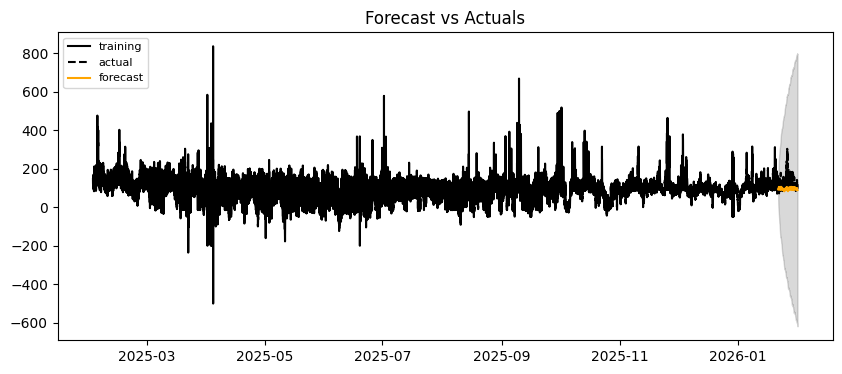

In [51]:
plot_forecast(forecast, train_price, test, confidence_int[:,0], confidence_int[:,1])

In [52]:
def plot_forecast_2(fc, train, test, ylim_low=None, ylim_up=None,
                    days_shown=None, upper=None, lower=None):
    is_confidence_int = isinstance(upper, np.ndarray) and isinstance(lower, np.ndarray)
    # Prepare plot series
    fc_series = pd.Series(fc, index=test.index)
    lower_series = pd.Series(upper, index=test.index) if is_confidence_int else None
    upper_series = pd.Series(lower, index=test.index) if is_confidence_int else None

    # Plot
    plt.figure(figsize=(10,4), dpi=100)
    plt.plot(train, label='training', color='black')
    plt.plot(test, label='actual', color='black', ls='--')
    plt.plot(fc_series, label='forecast', color='orange')
    if is_confidence_int:
        plt.fill_between(lower_series.index, lower_series, upper_series, color='k', alpha=.15)
    plt.title('Forecast vs Actuals')
    plt.legend(loc='upper left', fontsize=8)
    if days_shown is not None:
        end_date = test.index.max()
        print(end_date)
        start_date = end_date - pd.Timedelta(days=days_shown)
        print(start_date)
        plt.xlim(start_date, end_date)
    if ylim_low is not None and ylim_up is not None:
        plt.ylim(ylim_low, ylim_up)

    plt.show()

2026-02-01 00:00:00
2026-01-12 00:00:00


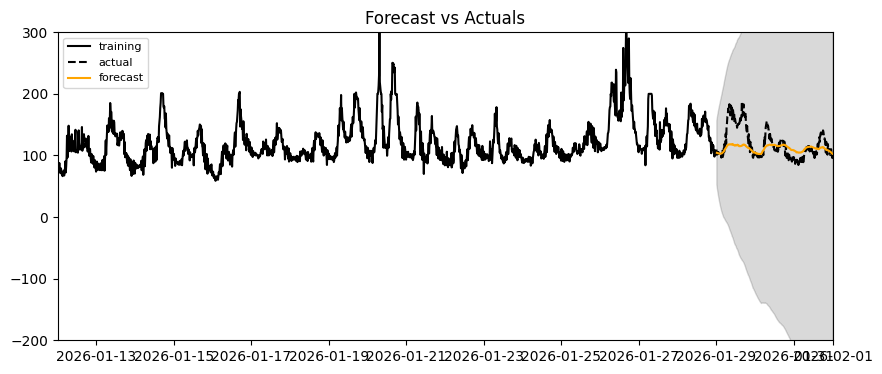

In [61]:
plot_forecast_2(forecast, train_price, test, ylim_low=-200, ylim_up=300, days_shown=20, upper=confidence_int[:,0], lower=confidence_int[:,1])